## Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data_util import *

In [3]:
get_files(r'V.[0|5].*_CutFre200.xls')

['V350_Case7_CutFre200.xls',
 'V300_Case3_CutFre200.xls',
 'V350_Case3_CutFre200.xls',
 'V300_Case7_CutFre200.xls',
 'V350_Case4_CutFre200.xls',
 'V300_Case4_CutFre200.xls',
 'V300_Case8_CutFre200.xls',
 'V350_Case8_CutFre200.xls',
 'V350_Case1_CutFre200.xls',
 'V300_Case5_CutFre200.xls',
 'V350_Case5_CutFre200.xls',
 'V300_Case1_CutFre200.xls',
 'V350_Case2_CutFre200.xls',
 'V300_Case6_CutFre200.xls',
 'V350_Case6_CutFre200.xls',
 'V300_Case2_CutFre200.xls']

In [4]:
get_files(r'V.[8].*_CutFre200.xls')

['V380_Case8_CutFre200.xls',
 'V380_Case2_CutFre200.xls',
 'V380_Case6_CutFre200.xls',
 'V380_Case1_CutFre200.xls',
 'V380_Case5_CutFre200.xls',
 'V380_Case4_CutFre200.xls',
 'V380_Case7_CutFre200.xls',
 'V380_Case3_CutFre200.xls']

In [5]:
import time

In [6]:
no_epochs=20
val_split=0.15
sequence_length = 16  # sequence length

#### Tranining Data set

In [7]:
train_df = read_data(get_files(r'V.[0|5].*_CutFre200.xls'),cut_precent=0.1) # case 1 -6 for traning
train_df.head()

,distance,acceleration,displacement,force
0,175.666667,9.164599,0.060525,117.414903
1,175.763889,8.131596,0.060492,124.159130
2,175.861111,8.379406,0.060468,121.688051
3,175.958333,9.957392,0.060452,109.649153
4,176.055556,11.845532,0.060446,95.294265


In [8]:
# Selecting the relevant features
train_features = train_df[['acceleration', 'displacement']]
train_target = train_df['force']

X_train, y_train = create_sequences(train_features, train_target, sequence_length)

#### Testing Data set

In [9]:
test_df = read_data(get_files(r'V.[8].*_CutFre200.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]
test_target = test_df['force']

X_test, y_test = create_sequences(test_features, test_target, sequence_length)

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Conv1D, Dense,LSTM,Bidirectional,Input,GRU,Flatten,Dropout,Attention
from tensorflow.keras import regularizers
from tensorflow import keras
from keras_self_attention import SeqSelfAttention

2024-05-05 11:27:58.318922: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [13]:
rnn_model = Sequential([
    SimpleRNN(32, input_shape=(sequence_length, 2), return_sequences=True),
    SimpleRNN(32, return_sequences=False),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mean_squared_error')
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 16, 32)         │         1,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,233 (12.63 KB)

 Trainable params: 3,233 (12.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
rnn_history = rnn_model.fit(X_train, y_train, epochs=no_epochs, validation_split=val_split, verbose=1)


Epoch 1/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 18769.4316 - val_loss: 2060.2939
Epoch 2/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - loss: 1541.6198 - val_loss: 784.5286
Epoch 3/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - loss: 587.6328 - val_loss: 360.9150
Epoch 4/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 342.5112 - val_loss: 308.6869
Epoch 5/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 314.2822 - val_loss: 361.5703
Epoch 6/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - loss: 305.3794 - val_loss: 344.9678
Epoch 7/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 299.1270 - val_loss: 316.0421
Epoch 8/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 304.0713 - val_loss: 325.0635
Epoch 9/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 289.3274 - val_loss: 319.5392
Epoch 10/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 25s 5ms/step - loss: 289.7833 - val_loss: 346.7846
Epoch 11/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 2

In [17]:
rnn_model.save("models/rnn_model.keras")
pd.DataFrame(data = rnn_history.history).to_csv("history/rnn_hist.csv")
time.sleep(60*5)

In [20]:
gru_model = Sequential([
    GRU(32, input_shape=(sequence_length, 2), return_sequences=True),
    GRU(32, return_sequences=False),
    # SeqSelfAttention(attention_activation='sigmoid'),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mean_squared_error')
gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 16, 32)         │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,825 (38.38 KB)

 Trainable params: 9,825 (38.38 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
gru_history = gru_model.fit(X_train, y_train, epochs=no_epochs, validation_split=val_split, verbose=1)

Epoch 1/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 56s 10ms/step - loss: 18084.2520 - val_loss: 2066.1501
Epoch 2/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 50s 9ms/step - loss: 1710.6161 - val_loss: 439.0261
Epoch 3/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - loss: 364.7589 - val_loss: 330.7019
Epoch 4/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 44s 8ms/step - loss: 297.9693 - val_loss: 305.6042
Epoch 5/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 47s 8ms/step - loss: 285.7408 - val_loss: 284.3376
Epoch 6/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 47s 8ms/step - loss: 277.3669 - val_loss: 302.6857
Epoch 7/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - loss: 271.5338 - val_loss: 289.2828
Epoch 8/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 48s 9ms/step - loss: 268.6165 - val_loss: 295.8672
Epoch 9/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 47s 8ms/step - loss: 272.5972 - val_loss: 336.0388
Epoch 10/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 47s 8ms/step - loss: 262.7532 - val_loss: 317.1568
Epoch 11/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - loss: 

In [22]:
gru_model.save("models/gru_model.keras")
pd.DataFrame(data = gru_history.history).to_csv("history/gru_hist.csv")
time.sleep(60*5)

In [23]:
gru_att_model = Sequential([
    GRU(32, input_shape=(sequence_length, 2), return_sequences=True),
    SeqSelfAttention(attention_activation='sigmoid'),
    GRU(32, return_sequences=False),
    Dense(1)
])
gru_att_model.compile(optimizer='adam', loss='mean_squared_error')
gru_att_model.summary()
gru_att_history = gru_att_model.fit(X_train, y_train, epochs=no_epochs, validation_split=val_split, verbose=1)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 16, 32)         │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ seq_self_attention              │ (None, 16, 32)         │         2,113 │
│ (SeqSelfAttention)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,938 (46.63 KB)

 Trainable params: 11,938 (46.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 82s 14ms/step - loss: 18262.9375 - val_loss: 2092.4312
Epoch 2/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 73s 13ms/step - loss: 2007.9520 - val_loss: 530.2892
Epoch 3/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 71s 13ms/step - loss: 448.2292 - val_loss: 320.5078
Epoch 4/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 69s 12ms/step - loss: 318.3425 - val_loss: 310.5027
Epoch 5/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 69s 12ms/step - loss: 301.4346 - val_loss: 320.3295
Epoch 6/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 73s 13ms/step - loss: 290.1800 - val_loss: 372.3119
Epoch 7/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 69s 12ms/step - loss: 282.3934 - val_loss: 303.3250
Epoch 8/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 66s 12ms/step - loss: 278.8035 - val_loss: 294.1761
Epoch 9/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 69s 12ms/step - loss: 274.7086 - val_loss: 297.5411
Epoch 10/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 61s 11ms/step - loss: 270.2136 - val_loss: 303.2698
Epoch 11/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 60s 11ms/ste

In [24]:
gru_att_model.save("models/gru_att_model.keras")
pd.DataFrame(data = gru_att_history.history).to_csv("history/gru_att_hist.csv")
time.sleep(60*5)

In [25]:
def cnn_gru_model(steps=sequence_length,feature_size=2, output_size=1,req=True):
    model = Sequential()
    model.add(Input(shape=(steps,feature_size)))
    model.add(Conv1D(64, 1, activation='relu'))
    model.add(GRU(32, return_sequences=True))
    model.add(GRU(32,return_sequences=False))
    model.add(Dense(output_size))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [26]:
cnn_gru_model = cnn_gru_model()
cnn_gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 16, 64)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 16, 32)         │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,969 (62.38 KB)

 Trainable params: 15,969 (62.38 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
cnn_gru_history = cnn_gru_model.fit(X_train, y_train,  epochs=no_epochs, validation_split=val_split, verbose=1)

Epoch 1/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 52s 9ms/step - loss: 18729.8574 - val_loss: 2145.9937
Epoch 2/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - loss: 2047.0250 - val_loss: 561.2667
Epoch 3/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 55s 10ms/step - loss: 443.3682 - val_loss: 295.6807
Epoch 4/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 58s 10ms/step - loss: 303.7714 - val_loss: 286.3748
Epoch 5/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 58s 10ms/step - loss: 286.2614 - val_loss: 287.4026
Epoch 6/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 57s 10ms/step - loss: 275.2255 - val_loss: 284.4556
Epoch 7/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 57s 10ms/step - loss: 267.2163 - val_loss: 288.7592
Epoch 8/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 56s 10ms/step - loss: 261.9949 - val_loss: 330.0983
Epoch 9/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 57s 10ms/step - loss: 253.2769 - val_loss: 296.7748
Epoch 10/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 57s 10ms/step - loss: 243.5825 - val_loss: 255.3512
Epoch 11/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 57s 10ms/step 

In [28]:
cnn_gru_model.save("models/cnn_gru_model.keras")
pd.DataFrame(data = cnn_gru_history.history).to_csv("history/cnn_gru_hist.csv")
time.sleep(60*5)

In [29]:
# reg = regularizers.l1_l2(0.01)
def lstm_model(steps=sequence_length,feature_size=2, output_size=1,req=True):
    model = Sequential()
    # model.add(Input(shape=(steps,feature_size)))
    # model.add(Conv1D(64, 1, activation='relu'))
    model.add(LSTM(32,input_shape=(sequence_length, 2), return_sequences=True))
    model.add(LSTM(32,return_sequences=False))
    model.add(Dense(output_size))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [30]:
lstm_model = lstm_model()
lstm_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16, 32)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,833 (50.13 KB)

 Trainable params: 12,833 (50.13 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
lstm_history = lstm_model.fit(X_train, y_train,  epochs=no_epochs, validation_split=val_split, verbose=1)

Epoch 1/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 18550.9434 - val_loss: 2117.8875
Epoch 2/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - loss: 1582.5990 - val_loss: 421.6795
Epoch 3/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - loss: 368.8305 - val_loss: 314.0670
Epoch 4/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - loss: 304.1814 - val_loss: 317.9236
Epoch 5/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - loss: 291.4511 - val_loss: 294.0137
Epoch 6/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 45s 8ms/step - loss: 284.3983 - val_loss: 301.1989
Epoch 7/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 44s 8ms/step - loss: 278.0979 - val_loss: 291.1115
Epoch 8/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - loss: 277.0142 - val_loss: 300.8869
Epoch 9/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 46s 8ms/step - loss: 270.4085 - val_loss: 321.7847
Epoch 10/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 45s 8ms/step - loss: 269.5935 - val_loss: 288.7559
Epoch 11/20
5562/5562 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - loss: 2

In [32]:
lstm_model.save("models/lstm_model.keras")
pd.DataFrame(data = lstm_history.history).to_csv("history/lstm_hist.csv")
time.sleep(60*5)

In [33]:
# def dnn_model(steps=sequence_length,feature_size=2, output_size=1,req=True):
#     model = Sequential()
#     model.add(Input(shape=(steps,feature_size)))
#     model.add(Flatten())
#     model.add(Dense(32))
#     model.add(Dense(32))
#     model.add(Dense(1))
#     model.compile(optimizer='adam', loss='mean_squared_error')
#     return model

# dnn_model = dnn_model()
# dnn_model.summary()

In [34]:
# dnn_history = dnn_model.fit(X_train, y_train,  epochs=no_epochs, validation_split=val_split, verbose=1)

In [35]:
# from sklearn.svm import SVR
# svr_rbf = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)
# svr_rbf.fit(train_df[['acceleration','displacement']], train_df.force)

In [36]:
# x = X_train.reshape(X_train.shape[0],-1)

In [37]:

# gru_model.save("models/gru_model.keras")
# lstm_model.save("models/lstm_model.keras")
# gru_att_model.save("models/gru_att_model.keras")

In [38]:
# def dnn_model2(steps=sequence_length,feature_size=2, output_size=1,req=True):
#     model = Sequential()
#     model.add(Dense(32,input_dim=feature_size))
#     model.add(Dense(32))
#     model.add(Dense(1))
#     model.compile(optimizer='adam', loss='mean_squared_error')
#     return model

# dnn_model1 = dnn_model2()
# dnn_model1.summary()

In [39]:
# dnn_history1 = dnn_model1.fit(train_features, train_target,  epochs=no_epochs, validation_split=val_split, verbose=1)

In [40]:
# rnn_model.load_weights("models/rnn_model.keras")
# new_model = tf.keras.models.load_model('my_model.keras')

In [41]:
# rnn_model = tf.keras.models.load_model("models/rnn_model.keras")
# dnn_model = tf.keras.models.load_model("models/dnn_model.keras")
# lstm_model = tf.keras.models.load_model("models/lstm_model.keras")

In [59]:
rnn_pred = rnn_model.predict(X_test)
gru_pred = gru_model.predict(X_test)
lstm_pred = lstm_model.predict(X_test)
cnn_gru_pred = cnn_gru_model.predict(X_test)
# dnn_pred1 = dnn_model1.predict(test_features[sequence_length:])

1036/1036 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


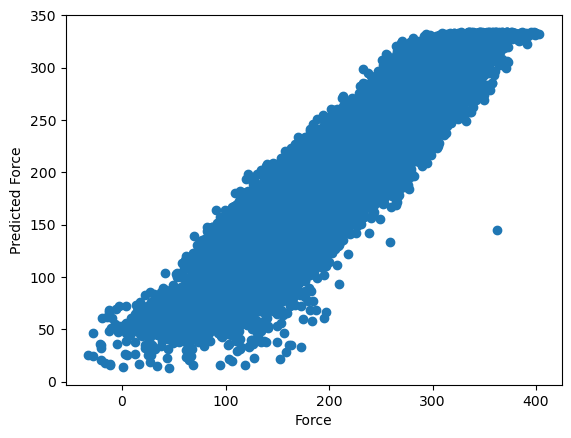

In [43]:
plt.scatter(y_test,lstm_pred);
plt.xlabel("Force")
plt.ylabel("Predicted Force");

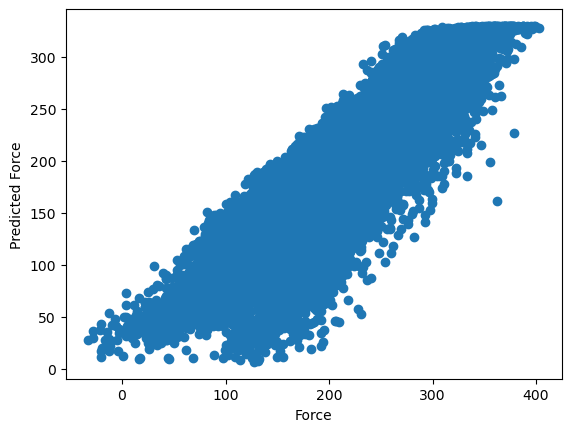

In [44]:
plt.scatter(y_test,cnn_gru_pred);
plt.xlabel("Force")
plt.ylabel("Predicted Force");

In [45]:
def plot_slot(start=500,end=601,filename="image"):
    epoch_count = range(start,end)

    plt.plot(epoch_count, y_test[start:end], 'ro-',linewidth=2.0,markevery=20)
    # plt.plot(epoch_count, dnn_pred1[start:end], 'm--',linewidth=2.0)
    # plt.plot(epoch_count, dnn_pred[start:end], 'b--',linewidth=2.0)
    plt.plot(epoch_count, gru_pred[start:end], 'm^--',linewidth=2.0,markevery=20)
    plt.plot(epoch_count, cnn_gru_pred[start:end], 'bX--',linewidth=2.0,markevery=20)
    plt.plot(epoch_count, rnn_pred[start:end], 'yh--',linewidth=2.0,markevery=20)
    plt.plot(epoch_count, lstm_pred[start:end], 'gd--',linewidth=2.0,markevery=20)
    plt.legend(['Force',"GRU","CNN-GRU", "RNN","LSTM"])
    plt.xlabel('Time Slots')
    plt.ylabel('Force')
    #plt.title(title)
    plt.grid(True)
    plt.savefig("images/"+filename+".pdf",dpi=200,format = "pdf")
    # plt.show()
    

In [45]:
SMALL_SIZE = 14
MEDIUM_SIZE = 14
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rcParams["figure.figsize"] = (8,6)
plt.style.use("classic")


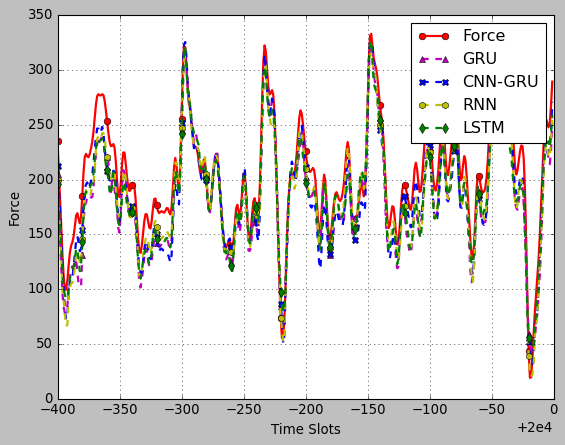

In [47]:
plot_slot(19600,20000,"ex1_trained_V300_V350_test_on_V380_Fre200")

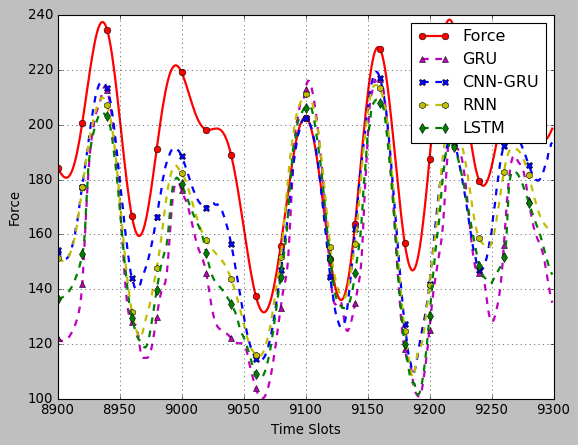

In [101]:
plot_slot(8900,9300,"ex30_trained_V300_V350_test_on_V380_Fre200")

In [49]:
df_val = pd.DataFrame(data = {
              # "DNN-TM":dnn_history.history["val_loss"],
              "RNN":rnn_history.history["val_loss"],
              "GRU":gru_history.history["loss"],
              "CNN_GRU":cnn_gru_history.history["loss"],
              "LSTM":rnn_history.history["val_loss"]
                                         })
df_val.head()
df_val.to_csv("history/val_loss.csv")

In [50]:
df_val = pd.DataFrame(data = {
              # "DNN-TM":dnn_history.history["loss"],
              "RNN":rnn_history.history["loss"],
              "GRU":gru_history.history["loss"],
              "CNN_GRU":cnn_gru_history.history["loss"],
              "LSTM":rnn_history.history["loss"]
                                         })
df_val.head()
df_val.to_csv("history/loss.csv")

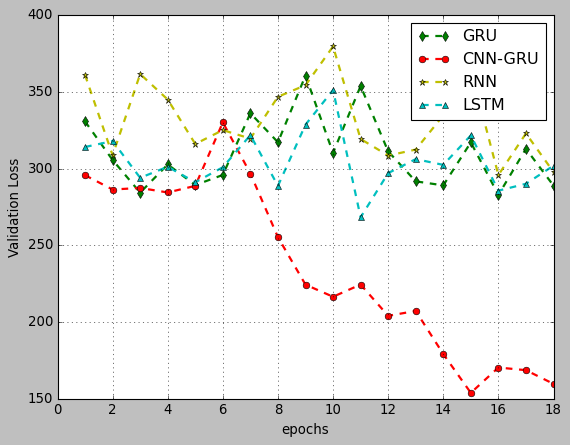

In [103]:
def plot_models_performance(gru=None, rnn=None, lstm=None,cnn_gru=None, title="Proctive Model"):
    lstm_accuracy = lstm.history['val_loss'][2:no_epochs]
    rnn_accuracy = rnn.history['val_loss'][2:no_epochs]
    gru_accuracy = gru.history['val_loss'][2:no_epochs]
    gru_att_acc = cnn_gru.history['val_loss'][2:no_epochs]


    # Create count of the number of epochs
    epoch_count = range(1, len(lstm_accuracy) + 1)

    # Visualize loss history
    plt.plot(epoch_count, gru_accuracy, 'gd--',linewidth=2.0)
    plt.plot(epoch_count, gru_att_acc, 'ro--',linewidth=2.0)
    plt.plot(epoch_count, rnn_accuracy, 'y*--',linewidth=2.0)
    plt.plot(epoch_count, lstm_accuracy, 'c^--',linewidth=2.0)
   
    plt.legend(['GRU','CNN-GRU', "RNN", "LSTM"])
    plt.xlabel('epochs')
    plt.ylabel('Validation Loss')
    plt.grid(True)
    plt.savefig("images/"+"val_loss.pdf",dpi=200,format = "pdf")

plot_models_performance(gru_history,rnn_history,lstm_history,cnn_gru_history,title="Adaptive Validation Loss")

In [3]:
def plot_models_performance(gru=None, rnn=None, lstm=None, gru_att=None,title="Proctive Model"):
    lstm_accuracy = lstm.history['loss'][2:no_epochs]
    rnn_accuracy = rnn.history['loss'][2:no_epochs]
    gru_accuracy = gru.history['loss'][2:no_epochs]
    gru_att_acc = gru_att.history['val_loss'][2:no_epochs]


    # Create count of the number of epochs
    epoch_count = range(1, len(lstm_accuracy) + 1)

    # Visualize loss history
    plt.plot(epoch_count, gru_accuracy, 'gd--',linewidth=2.0)
    plt.plot(epoch_count, gru_att_acc, 'ro--',linewidth=2.0)
    plt.plot(epoch_count, rnn_accuracy, 'y*--',linewidth=2.0)
    plt.plot(epoch_count, lstm_accuracy, 'c^--',linewidth=2.0)
    # plt.plot(epoch_count, deep_nn_accuracy, 'b--')
    plt.legend(['GRU','CNN-GRU', "RNN", "LSTM"])
    plt.xlabel('epochs')
    plt.ylabel('Loss')
    # plt.title(title)
    plt.grid(True)
    plt.savefig("images/"+"loss.pdf",dpi=200,format = "pdf")

plot_models_performance(gru_history,rnn_history,lstm_history,cnn_gru_history,title="Loss")

NameError: name 'gru_history' is not defined

In [53]:
test_df = read_data(get_files(r'.*Case[7]_CutFre20.xls'),cut_precent=0.1) # case 7 to 8 for testing
test_features = test_df[['acceleration', 'displacement']]
test_target = test_df['force']

X_test, y_test = create_sequences(test_features, test_target, sequence_length)

In [54]:
from sklearn.metrics import mean_squared_error

In [120]:
def plot_error(finame="bar"):
    rnn_pred = rnn_model.predict(X_test).reshape(-1)
    gru_pred = gru_model.predict(X_test).reshape(-1)
    lstm_pred = lstm_model.predict(X_test).reshape(-1)
    gru_att_pred = cnn_gru_model.predict(X_test).reshape(-1)
    # dnn_pred1 = dnn_model1.predict(test_features[sequence_length:])

    rnn_mse = mean_squared_error(y_test,rnn_pred)
    # dnn_tm_mse = mean_squared_error(dnn_pred, y_test)
    # dnn_mse = mean_squared_error(dnn_pred1, y_test)
    gru_mse = mean_squared_error(y_test,gru_pred)
    gru_att_mse = mean_squared_error(y_test,gru_att_pred)
    lstm_mse = mean_squared_error(y_test,lstm_pred)

    fig, ax = plt.subplots()
    fruits = ['RNN','GRU','CNN-GRU', 'LSTM']
    counts = [rnn_mse, gru_mse, gru_att_mse, lstm_mse]
    bar_labels = ['RNN','GRU','CNN-GRU', 'LSTM']
    bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:orange']

    ax.bar(fruits, counts, label=bar_labels, color=bar_colors)

    ax.set_ylabel('Mean Sqaure Error',fontsize=17) 
    # ax.set_title('Fruit supply by kind and color')
    ax.set_xlabel('Models',fontsize=17)
    plt.grid(True)

    plt.xticks(fontsize=17) 
    plt.yticks(fontsize=17) 
    # plt.show()
    plt.savefig("images/"+finame+".pdf",dpi=200,format = "pdf")
    return counts

1036/1036 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


[817.9012140884836, 1409.2226554933618, 622.4130087328977, 1395.0265422156776]

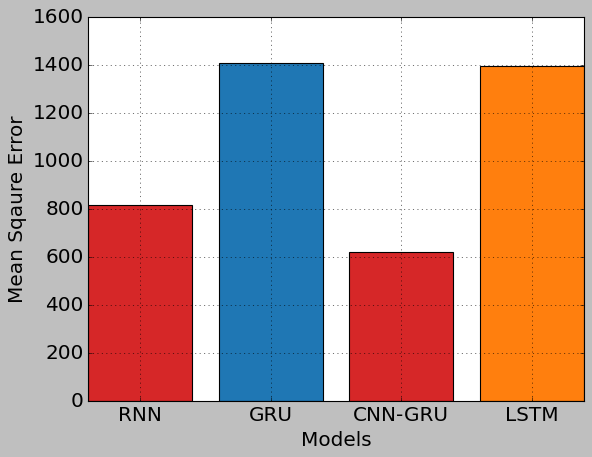

In [119]:
plot_error("trained_V300_V350_test_on_V380_Fre200")

In [3]:
import pandas as pd
data = pd.read_csv("history/loss.csv")

In [4]:
SMALL_SIZE = 14
MEDIUM_SIZE = 14
BIGGER_SIZE = 14

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rcParams["figure.figsize"] = (8,6)
plt.style.use("classic")


In [7]:
data.head()

,Unnamed: 0,RNN,GRU,CNN_GRU,LSTM
0,0,13291.537109,13121.728516,13494.293945,13291.537109
1,1,1350.441284,1150.029907,2133.654541,1350.441284
2,2,395.671875,368.657227,429.971375,395.671875
3,3,353.763397,330.399109,339.837189,353.763397
4,4,342.523651,321.320709,325.412994,342.523651


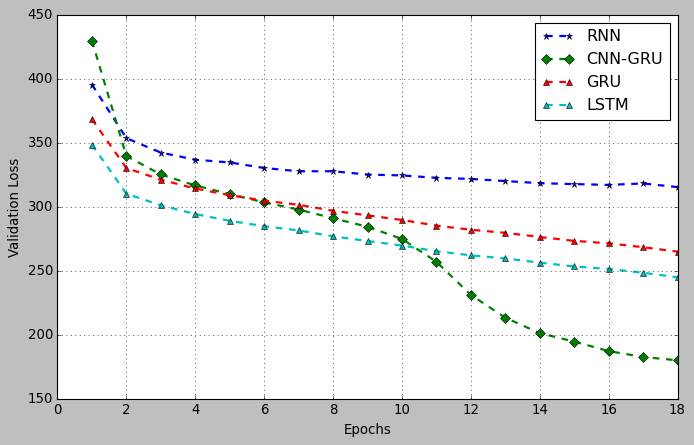

In [13]:
def plot_models_performance(data, title="Model Validation Loss"):
    # Extract validation loss for each model
    rnn_loss = data['RNN'][2:]
    gru_loss = data['GRU'][2:]
    cnn_gru_loss = data['CNN_GRU'][2:]
    lstm_loss = data['GRU'][2:] - 20  # your placeholder

    # Epoch count
    epoch_count = range(1, len(rnn_loss) + 1)

    plt.figure(figsize=(10, 6))

    # --- Apply bar-chart colour scheme ---
    plt.plot(epoch_count, rnn_loss,     'b*--', linewidth=2.0, label='RNN')        # blue
    plt.plot(epoch_count, cnn_gru_loss, 'gD--', linewidth=2.0, label='CNN-GRU')    # green
    plt.plot(epoch_count, gru_loss,     'r^--', linewidth=2.0, label='GRU')        # red
    plt.plot(epoch_count, lstm_loss,    'c^--', linewidth=2.0, label='LSTM')       # cyan

    # Labels and formatting
    plt.legend()
    plt.xlabel('Epochs')
    plt.ylabel('Validation Loss')
    plt.grid(True)
    plt.savefig("val_loss_plot.pdf", dpi=200, format="pdf")
    plt.show()

# Run
plot_models_performance(data, title="Validation Loss Across Models")